In [1]:
# %pip install datasets scikit-learn pandas numpy matplotlib seaborn joblib

In [2]:
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from datasets import load_dataset
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline


In [3]:
# 1. Load Dataset
# ---------------------------------------------------------
# Dataset: bitext/Bitext-customer-support-llm-chatbot-training-dataset
print("Loading Bitext Customer Support Dataset...")
dataset = load_dataset("bitext/Bitext-customer-support-llm-chatbot-training-dataset")
df = pd.DataFrame(dataset["train"])

print(f"Total samples: {len(df)}")
print(f"Original 27 intents: {df['intent'].nunique()} classes")


Loading Bitext Customer Support Dataset...


README.md:   0%|          | 0.00/11.9k [00:00<?, ?B/s]

Bitext_Sample_Customer_Support_Training_(…): reconstructing file:   0%|          |  0.00B / 19.2MB            

Bitext_Sample_Customer_Support_Training_(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/26872 [00:00<?, ? examples/s]

Total samples: 26872
Original 27 intents: 27 classes


In [4]:
# 2. Map 27 Intents to High-Level Routing Categories
# ---------------------------------------------------------
INTENT_ROUTING_MAP = {
    # Order Status
    "track_order": "order_status",
    "delivery_options": "order_status",
    "delivery_period": "order_status",

    # Order Management
    "cancel_order": "order_management",
    "change_order": "order_management",
    "place_order": "order_management",
    "change_shipping_address": "order_management",
    "set_up_shipping_address": "order_management",
    "check_cancellation_fee": "order_management",

    # Billing and Refunds
    "check_invoice": "billing_and_refunds",
    "get_invoice": "billing_and_refunds",
    "get_refund": "billing_and_refunds",
    "track_refund": "billing_and_refunds",
    "check_refund_policy": "billing_and_refunds",
    "payment_issue": "billing_and_refunds",
    "check_payment_methods": "billing_and_refunds",

    # Account Management
    "create_account": "account_management",
    "edit_account": "account_management",
    "delete_account": "account_management",
    "switch_account": "account_management",
    "recover_password": "account_management",
    "registration_problems": "account_management",
    "newsletter_subscription": "account_management",

    # Complaint & Escalation (Flagged for priority handling)
    "complaint": "complaint",
    "review": "complaint",
    "contact_customer_service": "complaint",
    "contact_human_agent": "complaint"
}

df["routing_intent"] = df["intent"].map(INTENT_ROUTING_MAP)

# Add synthetic greeting/goodbye/gratitude samples for complete small-talk coverage
small_talk_samples = [
    ("hello", "greeting_smalltalk"),
    ("hi there", "greeting_smalltalk"),
    ("good morning", "greeting_smalltalk"),
    ("hey", "greeting_smalltalk"),
    ("bye", "greeting_smalltalk"),
    ("goodbye", "greeting_smalltalk"),
    ("see you later", "greeting_smalltalk"),
    ("thank you", "greeting_smalltalk"),
    ("thanks for your help", "greeting_smalltalk"),
    ("appreciate it", "greeting_smalltalk"),
]
small_talk_df = pd.DataFrame(small_talk_samples, columns=["instruction", "routing_intent"])
# Replicate slightly to give adequate representation in training
small_talk_df = pd.concat([small_talk_df] * 50, ignore_index=True)

df_combined = pd.concat([df[["instruction", "routing_intent"]], small_talk_df], ignore_index=True)

print("\nRouting Categories Distribution:")
print(df_combined["routing_intent"].value_counts())



Routing Categories Distribution:
routing_intent
billing_and_refunds    6989
account_management     6985
order_management       5913
complaint              3996
order_status           2989
greeting_smalltalk      500
Name: count, dtype: int64


In [5]:
# 3. Stratified Train/Test Split
# ---------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    df_combined["instruction"],
    df_combined["routing_intent"],
    test_size=0.2,
    random_state=42,
    stratify=df_combined["routing_intent"]
)

print(f"\nTrain set: {len(X_train)} samples | Test set: {len(X_test)} samples")



Train set: 21897 samples | Test set: 5475 samples


In [6]:
# 4. Build Pipeline (TF-IDF + Logistic Regression)

pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        ngram_range=(1, 2),
        sublinear_tf=True,
        max_features=25000
        )),
    ("clf", LogisticRegression(
        C=5.0,
        max_iter=1000,
        class_weight="balanced",
        random_state=42))
])

Training intent classifier...

Classification Report (Test Set):
                     precision    recall  f1-score   support

 account_management     0.9986    1.0000    0.9993      1397
billing_and_refunds     0.9993    0.9979    0.9986      1398
          complaint     1.0000    0.9975    0.9987       799
 greeting_smalltalk     1.0000    1.0000    1.0000       100
   order_management     0.9966    0.9992    0.9979      1183
       order_status     0.9966    0.9950    0.9958       598

           accuracy                         0.9984      5475
          macro avg     0.9985    0.9982    0.9984      5475
       weighted avg     0.9984    0.9984    0.9984      5475



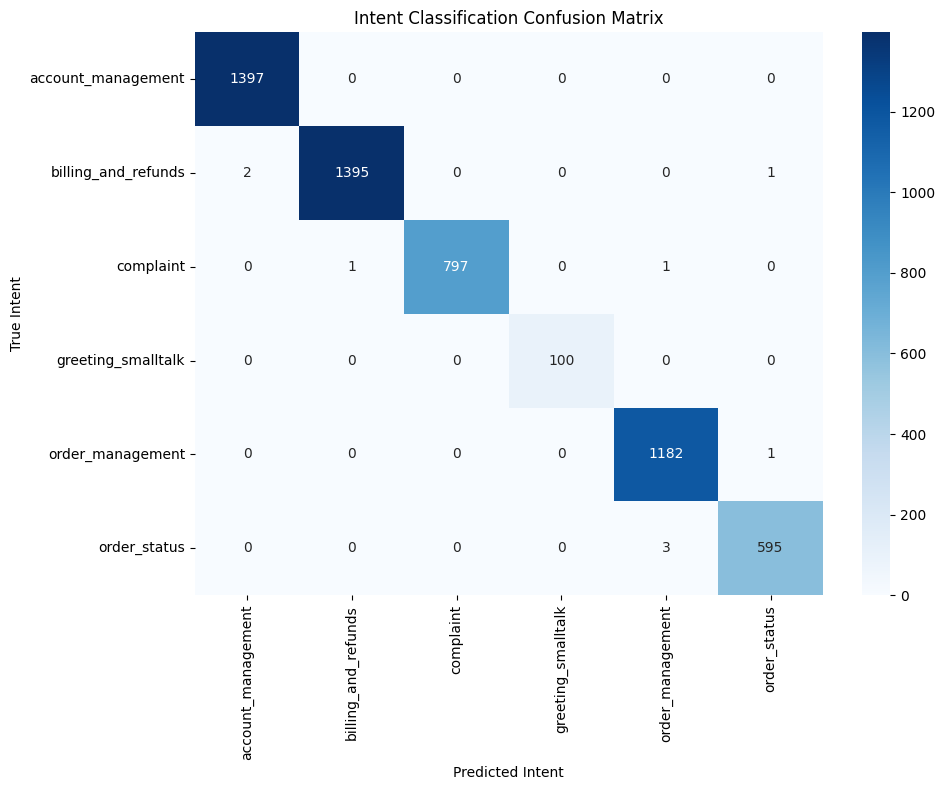

In [7]:
# ---------------------------------------------------------
# 5. Train & Evaluate
# ---------------------------------------------------------
print("Training intent classifier...")
pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)
labels = sorted(list(set(y_test)))

print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_pred, digits=4))

# Confusion Matrix Heatmap
cm = confusion_matrix(y_test, y_pred, labels=labels)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted Intent")
plt.ylabel("True Intent")
plt.title("Intent Classification Confusion Matrix")
plt.tight_layout()
plt.savefig("intent_confusion_matrix.png", dpi=300)
plt.show()


In [8]:

# ---------------------------------------------------------
# 6. Save Pipeline & Metadata
# ---------------------------------------------------------
joblib.dump(pipeline, "intent_classifier.joblib")
print("Saved pipeline successfully to 'intent_classifier.joblib'")

Saved pipeline successfully to 'intent_classifier.joblib'


In [9]:
import joblib
import numpy as np

class IntentRoutingEngine:
    def __init__(self, model_path: str = "intent_classifier.joblib", confidence_threshold: float = 0.45):
        self.model = joblib.load(model_path)
        self.confidence_threshold = confidence_threshold

    def classify_and_route(self, text: str) -> dict:
        probs = self.model.predict_proba([text])[0]
        max_idx = np.argmax(probs)
        confidence = float(probs[max_idx])
        predicted_intent = self.model.classes_[max_idx]

        # Handle out of scope queries below confidence threshold
        if confidence < self.confidence_threshold:
            predicted_intent = "out_of_scope"

        # Determine downstream pipeline routing action
        routing_action = self._determine_route(predicted_intent)

        return {
            "query": text,
            "intent": predicted_intent,
            "confidence": round(confidence, 4),
            "routing_action": routing_action
        }

    def _determine_route(self, intent: str) -> str:
        if intent == "greeting_smalltalk":
            return "DIRECT_RESPONSE"  # Bypass RAG, reply with canned greeting
        elif intent == "complaint":
            return "ESCALATE_OR_PRIORITY_RAG"  # Route to human agent or apologize before RAG
        elif intent == "out_of_scope":
            return "FALLBACK_ESCALATION"  # Inform user and offer human support
        else:
            return "EXECUTE_RAG_PIPELINE"  # Standard retrieval from Bitext knowledge base

# Quick Sanity Check
if __name__ == "__main__":
    router = IntentRoutingEngine()

    test_queries = [
        "Hi, good morning!",
        "Where is my package? The tracking number is 987123.",
        "I need to cancel my order immediately.",
        "Can I get a full refund for my damaged item?",
        "I forgot my account password and need to reset it.",
        "Your service is terrible, I want to file an official complaint!",
        "What is the weather like in Paris right now?"  # Unrelated / Out of scope
    ]

    for q in test_queries:
        res = router.classify_and_route(q)
        print(f"Query: \"{res['query']}\"")
        print(f"  -> Intent: [{res['intent']}] | Action: [{res['routing_action']}] (Confidence: {res['confidence']})\n")

Query: "Hi, good morning!"
  -> Intent: [greeting_smalltalk] | Action: [DIRECT_RESPONSE] (Confidence: 0.9992)

Query: "Where is my package? The tracking number is 987123."
  -> Intent: [order_status] | Action: [EXECUTE_RAG_PIPELINE] (Confidence: 0.9219)

Query: "I need to cancel my order immediately."
  -> Intent: [order_management] | Action: [EXECUTE_RAG_PIPELINE] (Confidence: 0.7257)

Query: "Can I get a full refund for my damaged item?"
  -> Intent: [billing_and_refunds] | Action: [EXECUTE_RAG_PIPELINE] (Confidence: 0.9377)

Query: "I forgot my account password and need to reset it."
  -> Intent: [account_management] | Action: [EXECUTE_RAG_PIPELINE] (Confidence: 0.993)

Query: "Your service is terrible, I want to file an official complaint!"
  -> Intent: [complaint] | Action: [ESCALATE_OR_PRIORITY_RAG] (Confidence: 0.994)

Query: "What is the weather like in Paris right now?"
  -> Intent: [out_of_scope] | Action: [FALLBACK_ESCALATION] (Confidence: 0.2833)

